In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import gc
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    TimeDistributed, LSTM, Dense, Dropout,
    Flatten, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("All libraries imported")
print("TensorFlow version:", tf.__version__)

2026-05-04 06:21:58.203141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777875718.500608      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777875718.596447      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777875719.356390      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777875719.356436      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777875719.356440      57 computation_placer.cc:177] computation placer alr

All libraries imported
TensorFlow version: 2.19.0


In [2]:
DATASET_PATH = "/kaggle/input/datasets/pypiahmad/realistic-action-recognition-ucf50/UCF50"

# ── RAM-safe settings ────────────────────────────────────────────────
# Kaggle free RAM = 13 GB
# These settings use approximately 2-3 GB — very safe
MAX_VIDEOS   = 40    # videos per class
NUM_FRAMES   = 20    # frames per video
FRAME_HEIGHT = 64    # frame height in pixels
FRAME_WIDTH  = 64    # frame width in pixels

# Model settings
NUM_CLASSES  = 30
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DROPOUT_RATE = 0.5

# Training settings
BATCH_SIZE    = 8
EPOCHS        = 100
LEARNING_RATE = 0.0001
SEED          = 42

SELECTED_CLASSES = [
    # Original 18
    "Basketball",
    "Diving",
    "HorseRace",
    "JumpRope",
    "VolleyballSpiking",
    "WalkingWithDog",
    "BenchPress",
    "Biking",
    "GolfSwing",
    "HighJump",
    "Kayaking",
    "PullUps",
    "PushUps",
    "RopeClimbing",
    "SkateBoarding",
    "SoccerJuggling",
    "Swing",
    "TrampolineJumping",
    "BaseballPitch",
    "Billiards",
    "Drumming",
    "Fencing",
    "HulaHoop",
    "JugglingBalls",
    "MilitaryParade",
    "PlayingGuitar",
    "PlayingPiano",
    "PlayingViolin",
    "Punch",
    "Skiing",
]

print("Configuration set")
print(f"  Classes      : {NUM_CLASSES}")
print(f"  Frames/video : {NUM_FRAMES}")
print(f"  Resolution   : {FRAME_HEIGHT}x{FRAME_WIDTH}")
print(f"  Max videos   : {MAX_VIDEOS} per class")

estimated_ram = (MAX_VIDEOS * NUM_CLASSES * NUM_FRAMES * FRAME_HEIGHT * FRAME_WIDTH * 3 * 4) / 1e9
print(f"\n  Estimated RAM for X : {estimated_ram:.2f} GB")
if estimated_ram < 5:
    print("  RAM looks safe")
else:
    print("  WARNING: reduce MAX_VIDEOS or FRAME size")

Configuration set
  Classes      : 30
  Frames/video : 20
  Resolution   : 64x64
  Max videos   : 40 per class

  Estimated RAM for X : 1.18 GB
  RAM looks safe


In [3]:
print("Checking class folders...\n")

missing = []
found   = []

for cls in SELECTED_CLASSES:
    path = os.path.join(DATASET_PATH, cls)
    if os.path.exists(path):
        count = len(os.listdir(path))
        found.append(cls)
        print(f"  OK   {cls:<25}  {count} videos")
    else:
        missing.append(cls)
        print(f"  MISSING  {cls:<25}  folder not found")

print(f"\nFound   : {len(found)} classes")
print(f"Missing : {len(missing)} classes")

if missing:
    print("\nThese folders were not found. Check spelling:")
    for m in missing:
        print(f"   -> {m}")
    print("\nAll available folders in dataset:")
    for f in sorted(os.listdir(DATASET_PATH)):
        print(f"   {f}")

Checking class folders...

  OK   Basketball                 137 videos
  OK   Diving                     153 videos
  OK   HorseRace                  127 videos
  OK   JumpRope                   148 videos
  OK   VolleyballSpiking          116 videos
  OK   WalkingWithDog             123 videos
  OK   BenchPress                 160 videos
  OK   Biking                     145 videos
  OK   GolfSwing                  142 videos
  OK   HighJump                   123 videos
  OK   Kayaking                   157 videos
  OK   PullUps                    120 videos
  OK   PushUps                    106 videos
  OK   RopeClimbing               130 videos
  OK   SkateBoarding              120 videos
  OK   SoccerJuggling             156 videos
  OK   Swing                      137 videos
  OK   TrampolineJumping          119 videos
  OK   BaseballPitch              150 videos
  OK   Billiards                  150 videos
  OK   Drumming                   161 videos
  OK   Fencing              

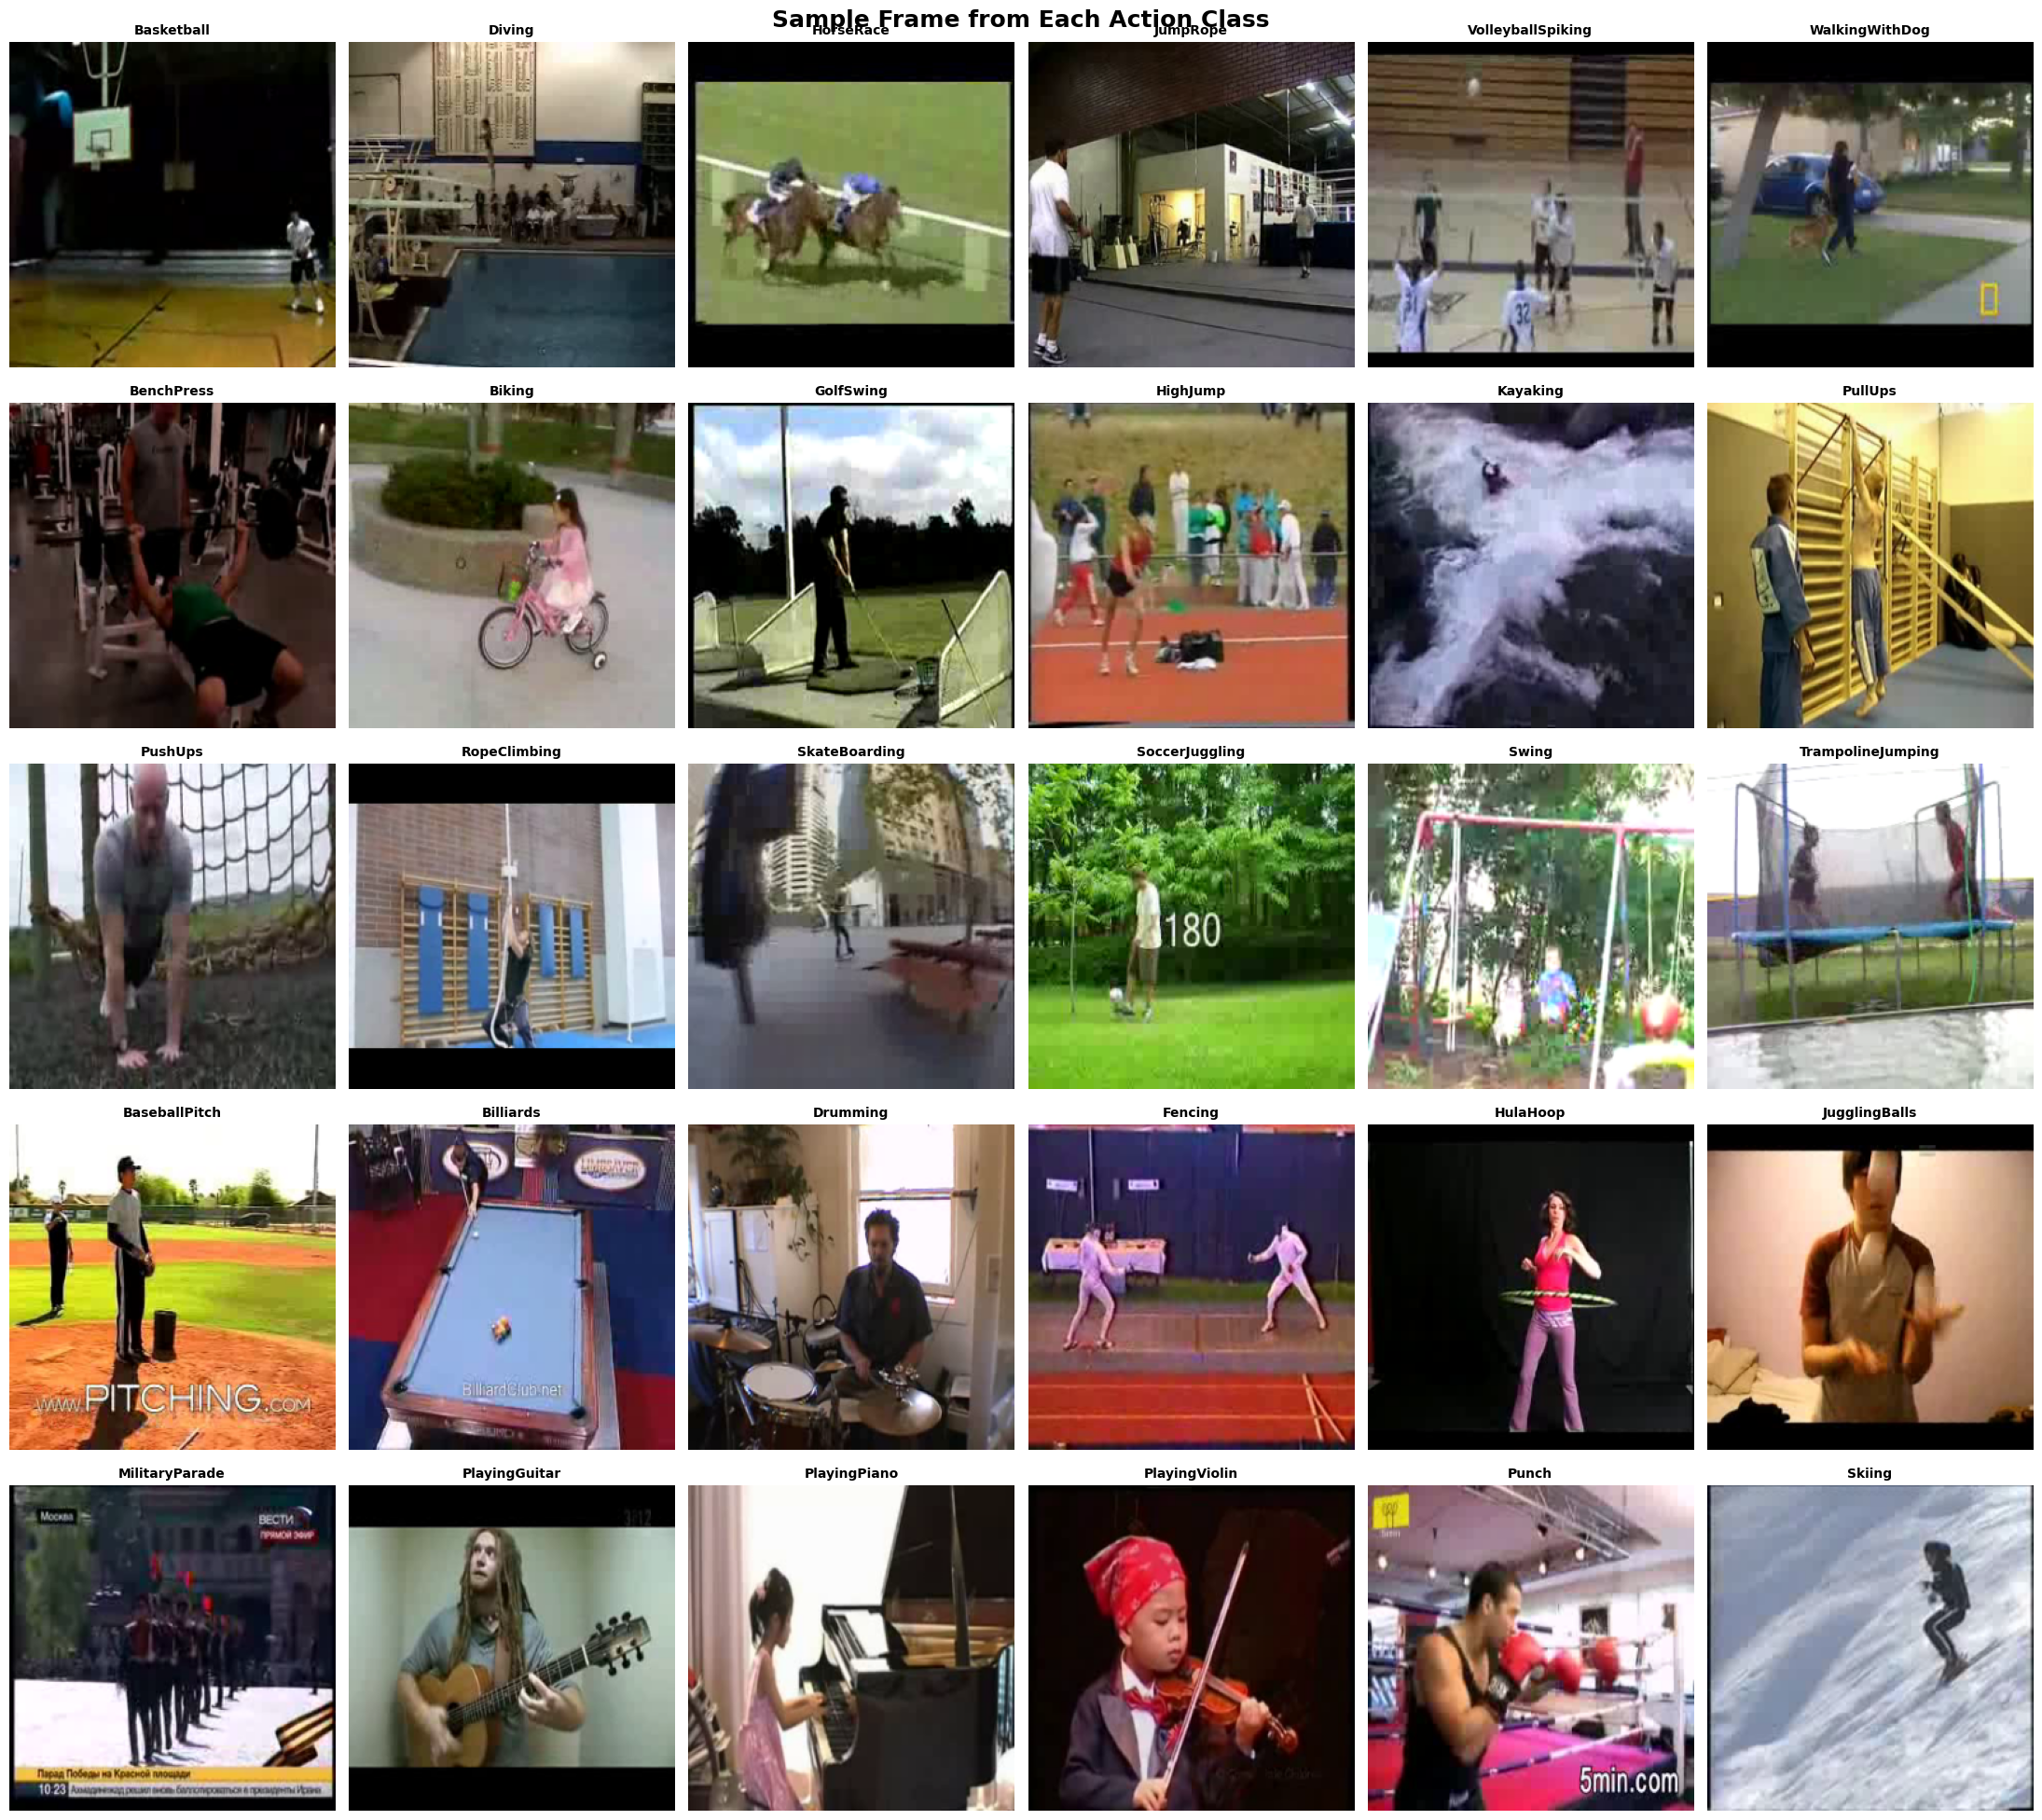

In [4]:
def show_sample_frames(classes, dataset_path):
    num_classes = len(classes)
    cols = 6
    rows = (num_classes + cols - 1) // cols  # auto rows

    fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 4))
    axes = axes.flatten()

    for i, cls in enumerate(classes):
        cls_path = os.path.join(dataset_path, cls)
        if not os.path.exists(cls_path):
            axes[i].set_title(f"{cls}\nNOT FOUND", fontsize=9, color='red')
            axes[i].axis('off')
            continue

        videos = os.listdir(cls_path)
        if not videos:
            axes[i].set_title(f"{cls}\nEMPTY", fontsize=9, color='red')
            axes[i].axis('off')
            continue

        video_path = os.path.join(cls_path, videos[0])
        cap = cv2.VideoCapture(video_path)
        ret, frame = cap.read()
        cap.release()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (256, 256))
            axes[i].imshow(frame)

        axes[i].set_title(cls, fontsize=10, fontweight='bold')
        axes[i].axis('off')

    # Hide empty slots
    for j in range(num_classes, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Sample Frame from Each Action Class", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_frames(SELECTED_CLASSES, DATASET_PATH)

In [5]:
def augment_frames(frames):
    augmented = frames.copy()

    # 1. Random horizontal flip
    if random.random() < 0.5:
        augmented = augmented[:, :, ::-1, :]

    # 2. Random brightness
    brightness = random.uniform(0.7, 1.3)
    augmented  = np.clip(augmented * brightness, 0.0, 1.0)

    # 3. Random noise
    if random.random() < 0.3:
        noise     = np.random.normal(0, 0.02, augmented.shape)
        augmented = np.clip(augmented + noise, 0.0, 1.0)

    # 4. Random zoom
    if random.random() < 0.4:
        h, w   = augmented.shape[1], augmented.shape[2]
        crop   = int(h * 0.1)
        zoomed = []
        for frame in augmented:
            cropped = frame[crop:h-crop, crop:w-crop, :]
            resized = cv2.resize(cropped, (w, h))
            zoomed.append(resized)
        augmented = np.array(zoomed)

    return augmented.astype(np.float32)

print("Augmentation function ready")

Augmentation function ready


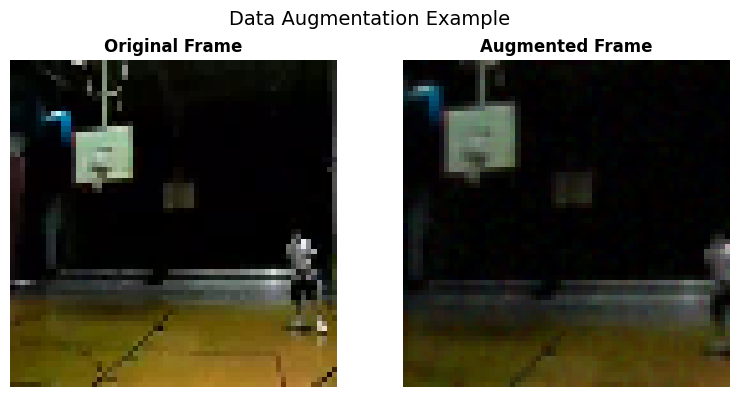

In [6]:
sample_cls_path = os.path.join(DATASET_PATH, SELECTED_CLASSES[0])
sample_vid_path = os.path.join(sample_cls_path, os.listdir(sample_cls_path)[0])

cap    = cv2.VideoCapture(sample_vid_path)
ret, f = cap.read()
cap.release()

if ret:
    f      = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
    f      = cv2.resize(f, (FRAME_WIDTH, FRAME_HEIGHT))
    f_norm = (f / 255.0).astype(np.float32)
    demo   = np.stack([f_norm] * NUM_FRAMES)
    aug    = augment_frames(demo)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(demo[0])
    axes[0].set_title("Original Frame", fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(aug[0])
    axes[1].set_title("Augmented Frame", fontweight='bold')
    axes[1].axis('off')
    plt.suptitle("Data Augmentation Example", fontsize=14)
    plt.tight_layout()
    plt.show()

In [7]:
def extract_frames(video_path, num_frames=NUM_FRAMES,
                   height=FRAME_HEIGHT, width=FRAME_WIDTH,
                   augment=False):
    frames = []
    cap    = cv2.VideoCapture(video_path)

    total_frames   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(total_frames // num_frames, 1)

    count = 0
    while len(frames) < num_frames and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (width, height))
            frame = (frame / 255.0).astype(np.float32)
            frames.append(frame)
        count += 1

    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else
                      np.zeros((height, width, 3), dtype=np.float32))

    frames = np.array(frames[:num_frames], dtype=np.float32)

    if augment:
        frames = augment_frames(frames)

    return frames

print("Frame extraction function ready")

Frame extraction function ready


In [8]:
# Clear memory from any previous run first
try:
    del X, y
    gc.collect()
except:
    pass

X       = []
y       = []
skipped = 0

print("Loading dataset...\n")

for class_idx, cls in enumerate(SELECTED_CLASSES):
    class_path = os.path.join(DATASET_PATH, cls)

    if not os.path.exists(class_path):
        print(f"  SKIP  {cls:<25}  folder not found")
        continue

    videos = sorted(os.listdir(class_path))[:MAX_VIDEOS]
    loaded = 0

    for video_name in videos:
        video_path = os.path.join(class_path, video_name)
        try:
            frames = extract_frames(video_path, augment=False)
            if frames.shape == (NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, 3):
                X.append(frames)
                y.append(class_idx)
                loaded += 1
            else:
                skipped += 1
        except Exception:
            skipped += 1

    print(f"  OK   {cls:<25}  {loaded} videos")

X = np.array(X, dtype=np.float32)
y = np.array(y)

gc.collect()

print(f"\nDataset loaded")
print(f"  X shape  : {X.shape}")
print(f"  y shape  : {y.shape}")
print(f"  Skipped  : {skipped} videos")
print(f"  RAM used : {X.nbytes / 1e9:.2f} GB")

Loading dataset...

  OK   Basketball                 40 videos
  OK   Diving                     40 videos
  OK   HorseRace                  40 videos
  OK   JumpRope                   40 videos
  OK   VolleyballSpiking          40 videos
  OK   WalkingWithDog             40 videos
  OK   BenchPress                 40 videos
  OK   Biking                     40 videos
  OK   GolfSwing                  40 videos
  OK   HighJump                   40 videos
  OK   Kayaking                   40 videos
  OK   PullUps                    40 videos
  OK   PushUps                    40 videos
  OK   RopeClimbing               40 videos
  OK   SkateBoarding              40 videos
  OK   SoccerJuggling             40 videos
  OK   Swing                      40 videos
  OK   TrampolineJumping          40 videos
  OK   BaseballPitch              40 videos
  OK   Billiards                  40 videos
  OK   Drumming                   40 videos
  OK   Fencing                    40 videos
  OK   HulaH

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = SEED,
    stratify     = y
)

print("Train/Test split done")
print(f"  Training : {X_train.shape[0]} videos")
print(f"  Testing  : {X_test.shape[0]} videos")

Train/Test split done
  Training : 960 videos
  Testing  : 240 videos


In [10]:
print("Applying augmentation to training data...")

X_aug = []
y_aug = []

for i in range(len(X_train)):
    aug = augment_frames(X_train[i])
    X_aug.append(aug)
    y_aug.append(y_train[i])

X_train = np.concatenate([X_train, np.array(X_aug, dtype=np.float32)], axis=0)
y_train = np.concatenate([y_train, np.array(y_aug)], axis=0)

# Free augmentation list from memory immediately
del X_aug, y_aug
gc.collect()

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

# Shuffle
shuffle_idx = np.random.permutation(len(X_train))
X_train     = X_train[shuffle_idx]
y_train_cat = y_train_cat[shuffle_idx]

print(f"Augmentation done")
print(f"  Training videos after augmentation : {X_train.shape[0]}")
print(f"  RAM now : {(X_train.nbytes + X_test.nbytes) / 1e9:.2f} GB")

Applying augmentation to training data...
Augmentation done
  Training videos after augmentation : 1920
  RAM now : 2.12 GB


In [12]:
# No pretrained weights — trains from scratch
# Less accurate than imagenet weights but works without internet

mobilenet = MobileNetV2(
    include_top = False,
    weights     = None,           # <-- changed from 'imagenet' to None
    input_shape = (FRAME_HEIGHT, FRAME_WIDTH, 3),
    pooling     = 'avg'
)
mobilenet.trainable = True        # train it fully since no pretrained weights

model = Sequential()

model.add(TimeDistributed(
    mobilenet,
    input_shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, 3)
))
model.add(TimeDistributed(BatchNormalization()))

model.add(LSTM(LSTM_UNITS_1, return_sequences=True))
model.add(Dropout(DROPOUT_RATE))

model.add(LSTM(LSTM_UNITS_2, return_sequences=False))
model.add(Dropout(DROPOUT_RATE))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    loss      = 'categorical_crossentropy',
    optimizer = Adam(learning_rate=LEARNING_RATE),
    metrics   = ['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 1280)       │         5,120 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 128)        │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046,622 (11.62 MB)

 Trainable params: 3,009,694 (11.48 MB)

 Non-trainable params: 36,928 (144.25 KB)

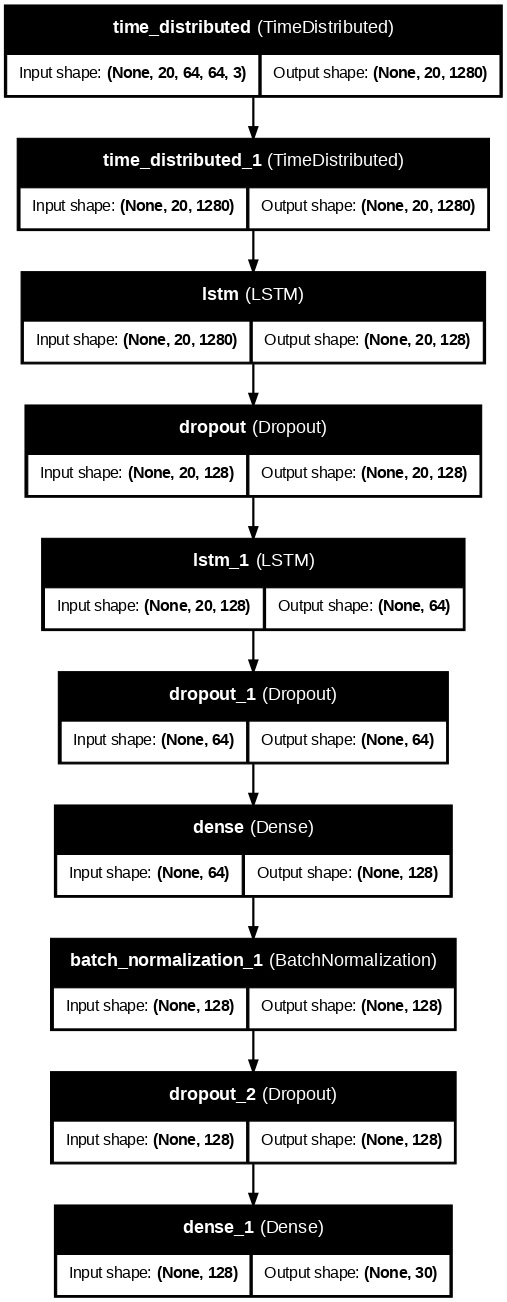

In [13]:
plot_model(model, show_shapes=True, show_layer_names=True, dpi=80)

In [14]:
os.makedirs("checkpoints", exist_ok=True)

early_stopping = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 15,
    restore_best_weights = True,
    verbose              = 1
)

model_checkpoint = ModelCheckpoint(
    filepath       = "checkpoints/best_model.keras",
    monitor        = 'val_loss',
    save_best_only = True,
    verbose        = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 7,
    min_lr   = 1e-7,
    verbose  = 1
)

print("Callbacks ready")
print("  EarlyStopping     - stops if no improvement for 15 epochs")
print("  ModelCheckpoint   - saves best weights automatically")
print("  ReduceLROnPlateau - halves learning rate if stuck for 7 epochs")

Callbacks ready
  EarlyStopping     - stops if no improvement for 15 epochs
  ModelCheckpoint   - saves best weights automatically
  ReduceLROnPlateau - halves learning rate if stuck for 7 epochs


In [15]:
print("Starting training...")
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")
print(f"  Max epochs       : {EPOCHS}")
print("-" * 50)

history = model.fit(
    X_train, y_train_cat,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_test, y_test_cat),
    callbacks       = [early_stopping, model_checkpoint, reduce_lr]
)

print(f"\nTraining complete")
print(f"  Ran for : {len(history.history['accuracy'])} epochs")
print(f"  Best val accuracy : {max(history.history['val_accuracy']):.2%}")

Starting training...
  Training samples : 1920
  Testing  samples : 240
  Max epochs       : 100
--------------------------------------------------
Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0400 - loss: 4.1666
Epoch 1: val_loss improved from inf to 3.44988, saving model to checkpoints/best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.0400 - loss: 4.1663 - val_accuracy: 0.0333 - val_loss: 3.4499 - learning_rate: 1.0000e-04
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0582 - loss: 3.9454
Epoch 2: val_loss improved from 3.44988 to 3.26813, saving model to checkpoints/best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.0582 - loss: 3.9453 - val_accuracy: 0.0750 - val_loss: 3.2681 - learning_rate: 1.0000e-04
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0768 - loss: 3.7501
Epoch 3: val_loss did not improve from 3.26813
240/240 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.0767 - lo

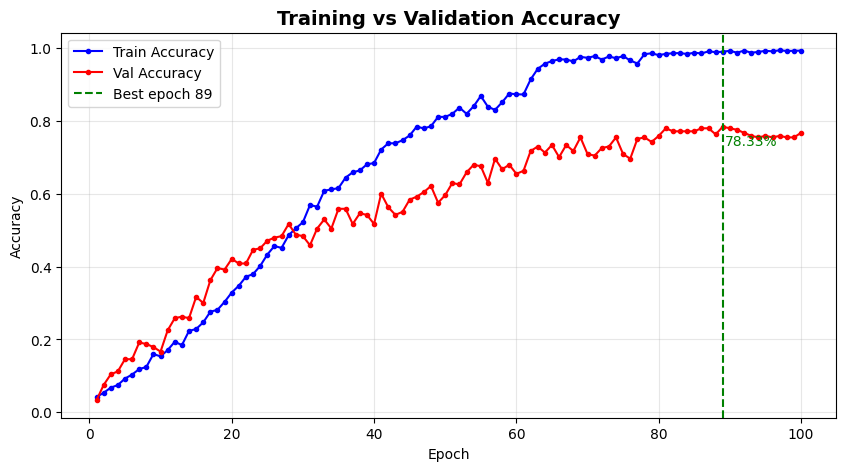

Best Validation Accuracy : 78.33%  at epoch 89


In [16]:
epochs_ran = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history.history['accuracy'],     'b-o', markersize=3, label='Train Accuracy')
plt.plot(epochs_ran, history.history['val_accuracy'], 'r-o', markersize=3, label='Val Accuracy')

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_acc   = max(history.history['val_accuracy'])
plt.axvline(best_epoch, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
plt.annotate(f'{best_acc:.2%}', xy=(best_epoch, best_acc),
             xytext=(best_epoch + 0.3, best_acc - 0.05),
             fontsize=10, color='green')

plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best Validation Accuracy : {best_acc:.2%}  at epoch {best_epoch}")

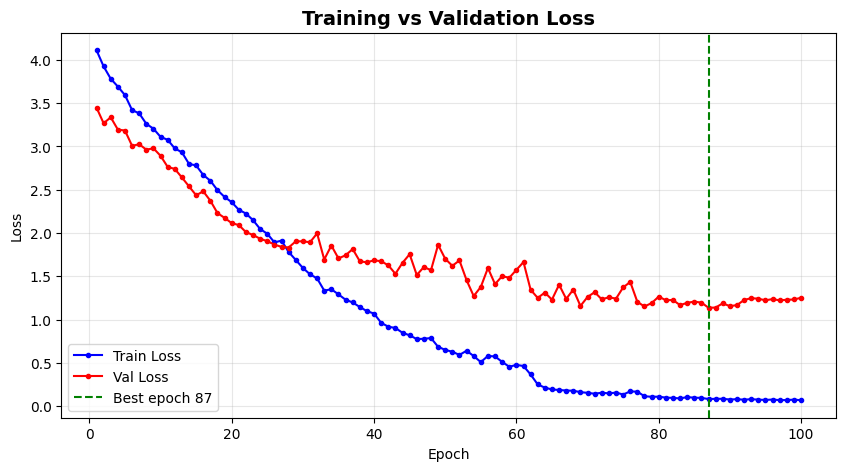

Best Validation Loss : 1.1375  at epoch 87


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history.history['loss'],     'b-o', markersize=3, label='Train Loss')
plt.plot(epochs_ran, history.history['val_loss'], 'r-o', markersize=3, label='Val Loss')

best_loss_epoch = np.argmin(history.history['val_loss']) + 1
best_loss       = min(history.history['val_loss'])
plt.axvline(best_loss_epoch, color='green', linestyle='--', label=f'Best epoch {best_loss_epoch}')

plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best Validation Loss : {best_loss:.4f}  at epoch {best_loss_epoch}")

In [18]:
best_model = load_model("checkpoints/best_model.keras")

test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)

print("Best Model — Test Set Evaluation:")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.2%}")

Best Model — Test Set Evaluation:
  Test Loss     : 1.1375
  Test Accuracy : 77.92%


In [19]:
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_test

print("Classification Report")
print("=" * 70)
print(classification_report(
    y_true, y_pred,
    target_names = SELECTED_CLASSES
))

Classification Report
                   precision    recall  f1-score   support

       Basketball       1.00      0.75      0.86         8
           Diving       0.88      0.88      0.88         8
        HorseRace       0.62      0.62      0.62         8
         JumpRope       1.00      1.00      1.00         8
VolleyballSpiking       0.75      0.75      0.75         8
   WalkingWithDog       0.40      0.25      0.31         8
       BenchPress       1.00      1.00      1.00         8
           Biking       0.38      0.38      0.38         8
        GolfSwing       1.00      0.88      0.93         8
         HighJump       0.71      0.62      0.67         8
         Kayaking       0.78      0.88      0.82         8
          PullUps       0.64      0.88      0.74         8
          PushUps       0.78      0.88      0.82         8
     RopeClimbing       0.75      0.75      0.75         8
    SkateBoarding       0.62      0.62      0.62         8
   SoccerJuggling       0.78     

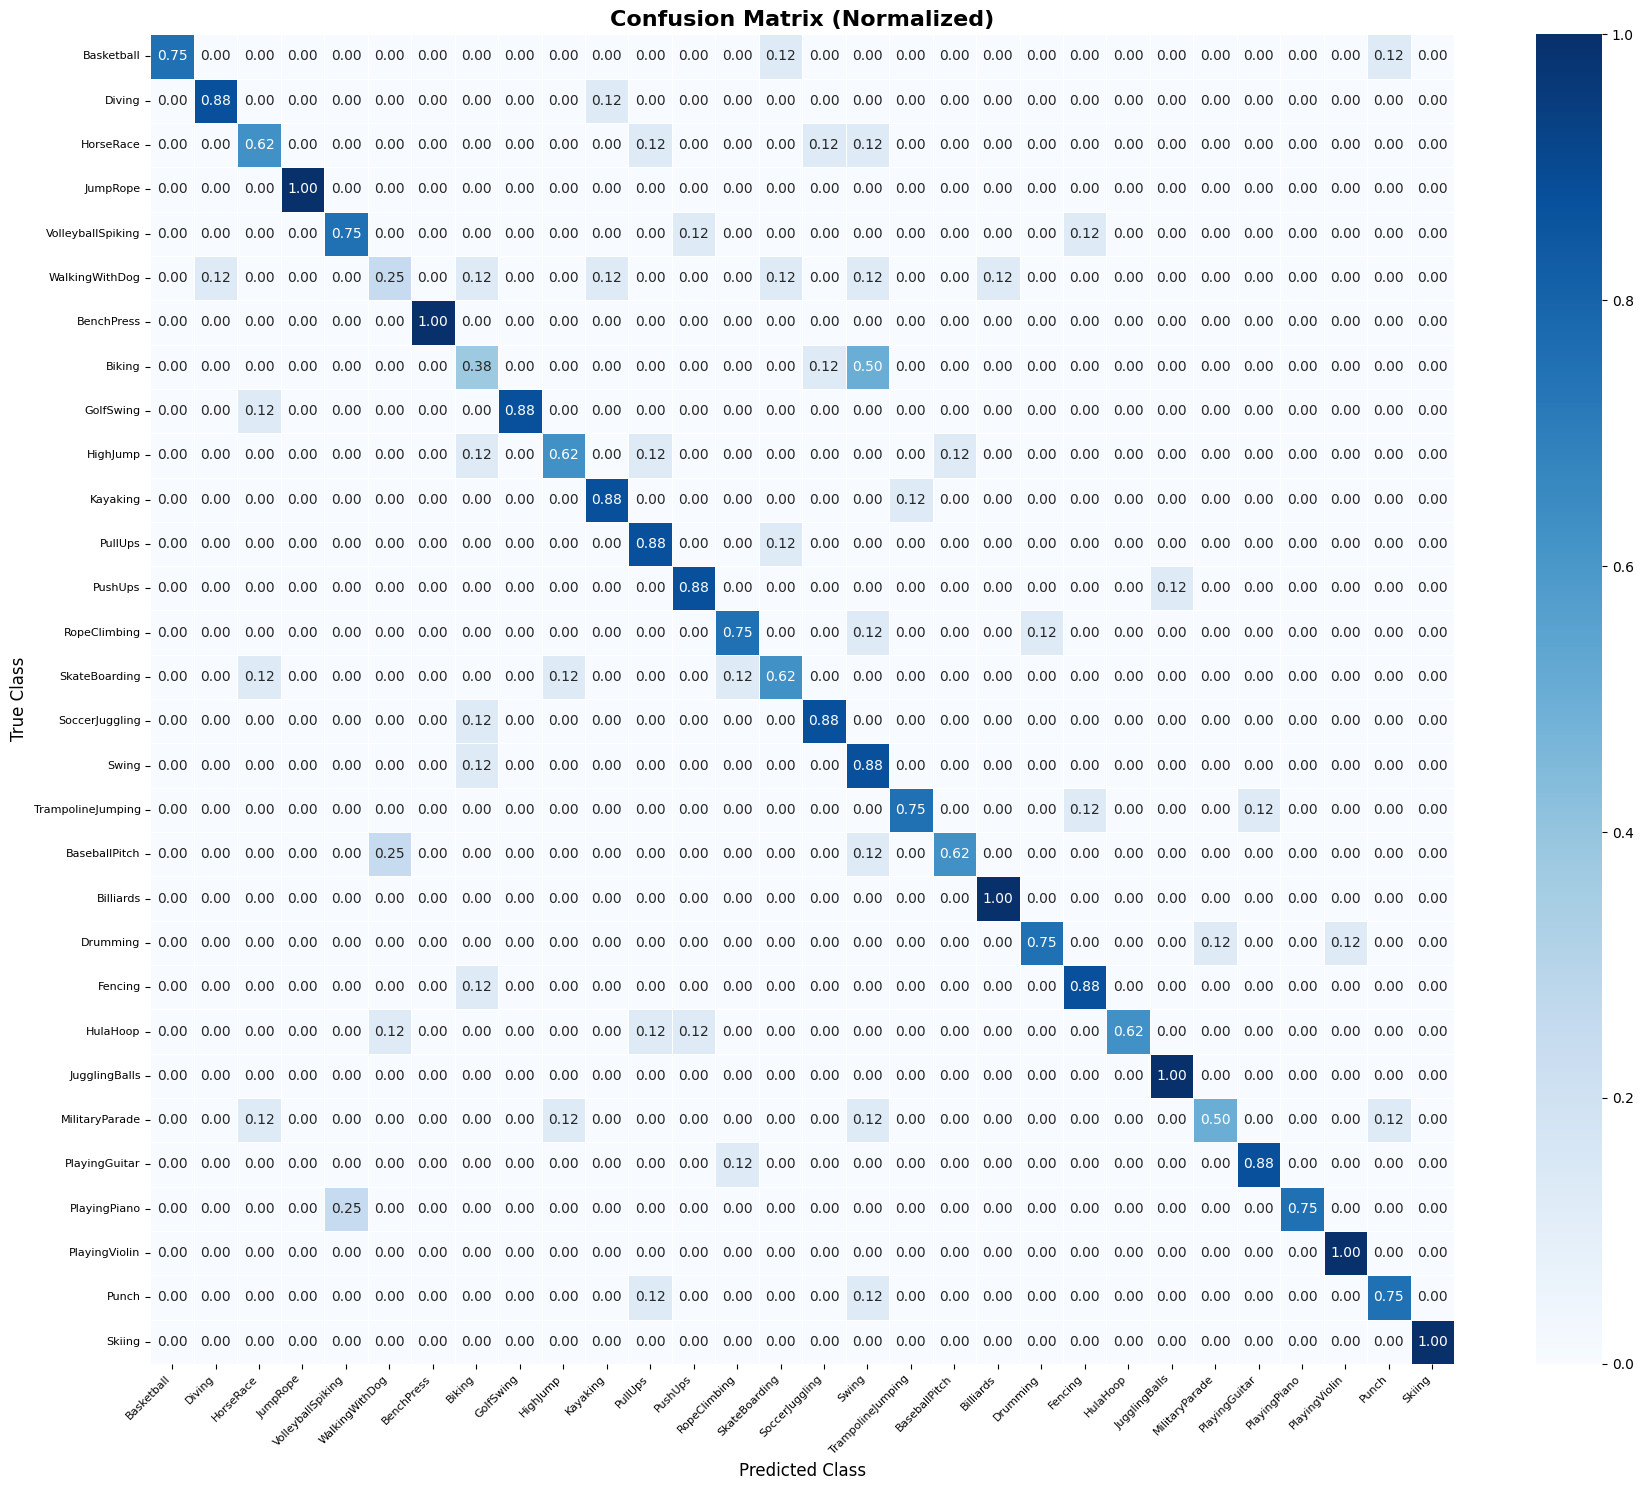

In [20]:
cm            = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm_normalized,
    annot       = True,
    fmt         = '.2f',
    cmap        = 'Blues',
    xticklabels = SELECTED_CLASSES,
    yticklabels = SELECTED_CLASSES,
    linewidths  = 0.5
)
plt.title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

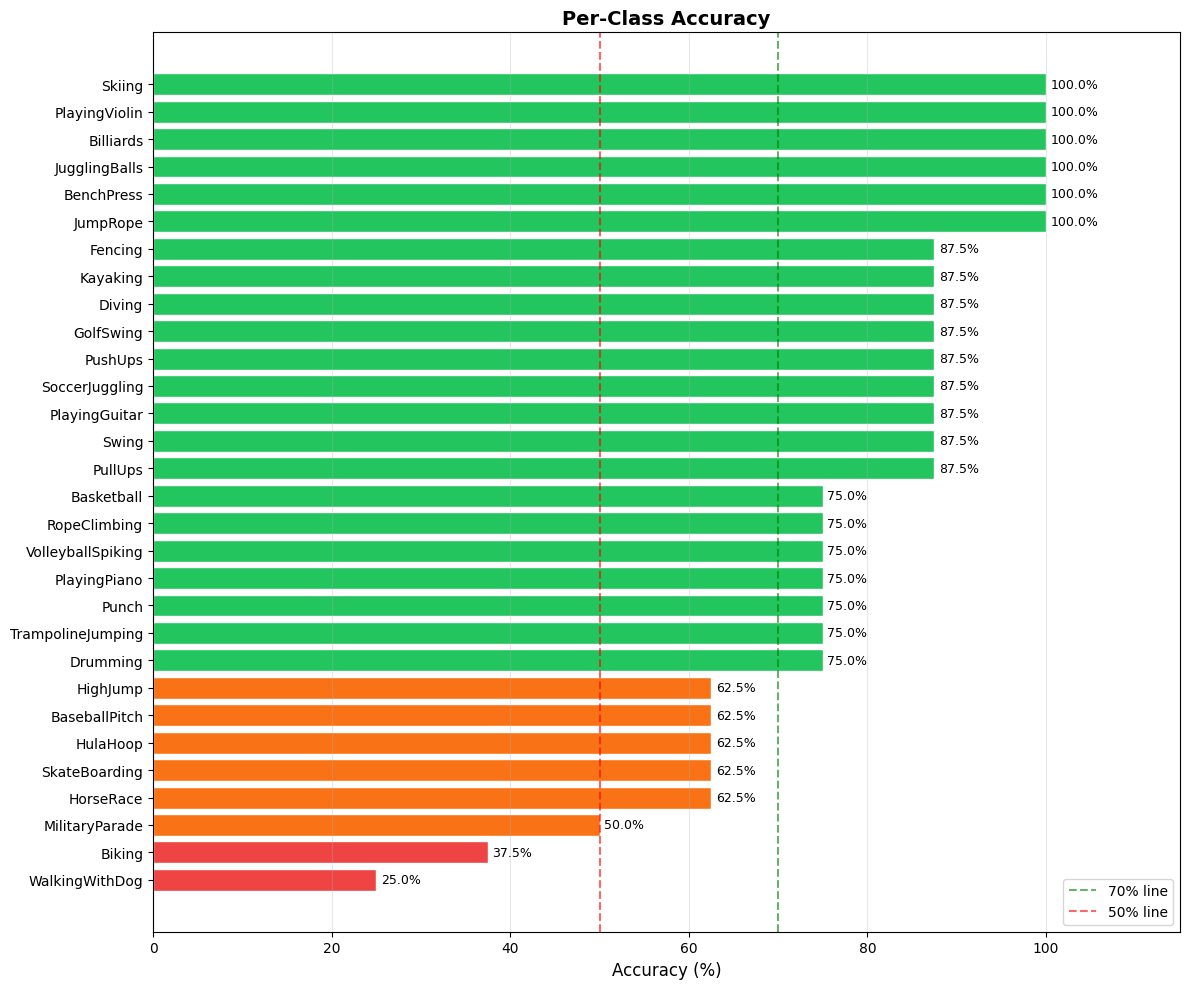

Best class   : Skiing  (100.00%)
Worst class  : WalkingWithDog  (25.00%)
Mean accuracy: 77.92%


In [21]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

sorted_idx = np.argsort(per_class_acc)
sorted_acc = per_class_acc[sorted_idx]
sorted_cls = [SELECTED_CLASSES[i] for i in sorted_idx]

colors = ['#ef4444' if a < 0.5 else '#f97316' if a < 0.7 else '#22c55e'
          for a in sorted_acc]

plt.figure(figsize=(12, 10))
bars = plt.barh(sorted_cls, sorted_acc * 100, color=colors, edgecolor='white')

for bar, acc in zip(bars, sorted_acc):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{acc:.1%}', va='center', fontsize=9)

plt.axvline(70, color='green', linestyle='--', alpha=0.6, label='70% line')
plt.axvline(50, color='red',   linestyle='--', alpha=0.6, label='50% line')
plt.xlabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlim(0, 115)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best class   : {sorted_cls[-1]}  ({sorted_acc[-1]:.2%})")
print(f"Worst class  : {sorted_cls[0]}  ({sorted_acc[0]:.2%})")
print(f"Mean accuracy: {per_class_acc.mean():.2%}")

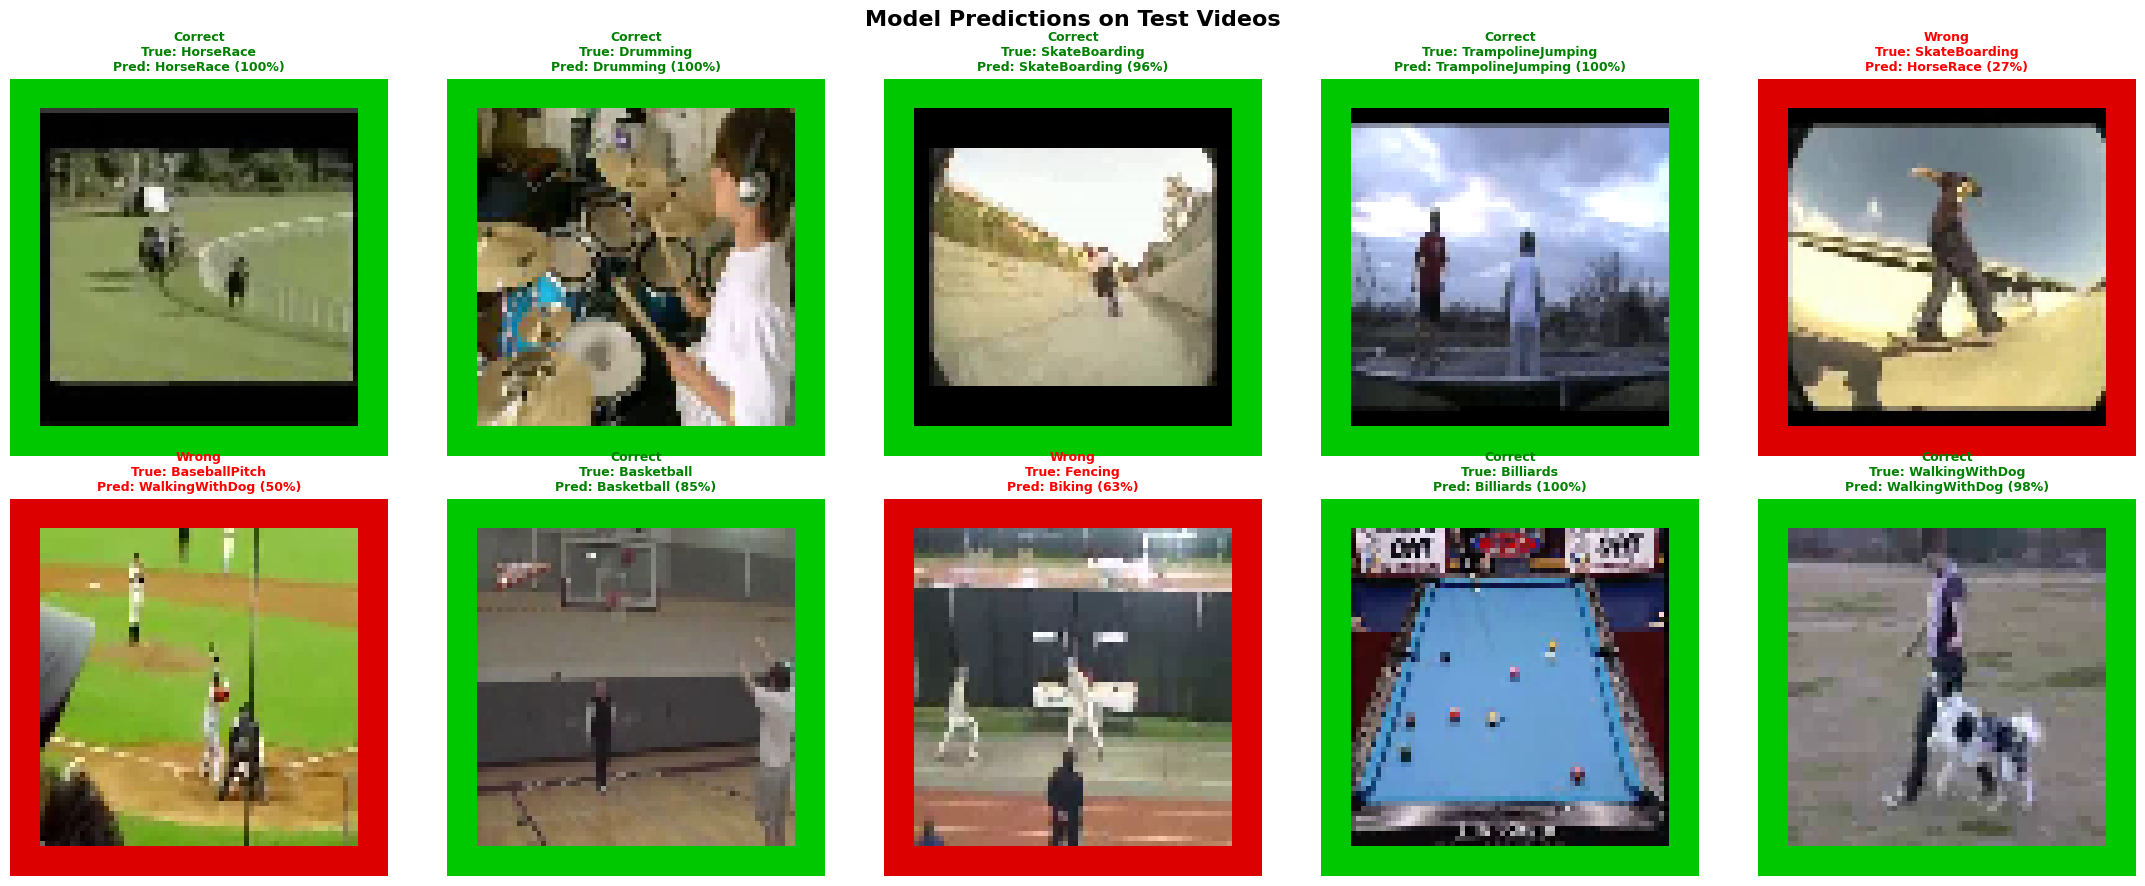

In [22]:
def show_predictions(model, X_test, y_test, class_names, n=10):
    indices = np.random.choice(len(X_test), n, replace=False)
    cols    = 5
    rows    = 2

    fig, axes = plt.subplots(rows, cols, figsize=(22, 9))
    axes      = axes.flatten()

    for i, idx in enumerate(indices):
        video      = X_test[idx]
        true_label = class_names[y_test[idx]]

        probs      = model.predict(np.expand_dims(video, axis=0), verbose=0)[0]
        pred_idx   = np.argmax(probs)
        pred_label = class_names[pred_idx]
        confidence = probs[pred_idx]
        correct    = (pred_label == true_label)

        mid_frame = (video[len(video) // 2] * 255).astype(np.uint8)
        color     = (0, 200, 0) if correct else (220, 0, 0)
        framed    = cv2.copyMakeBorder(mid_frame, 6, 6, 6, 6,
                                       cv2.BORDER_CONSTANT, value=color)

        axes[i].imshow(framed)
        status = "Correct" if correct else "Wrong"
        axes[i].set_title(
            f"{status}\nTrue: {true_label}\nPred: {pred_label} ({confidence:.0%})",
            fontsize=9,
            color='green' if correct else 'red',
            fontweight='bold'
        )
        axes[i].axis('off')

    plt.suptitle("Model Predictions on Test Videos", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(best_model, X_test, y_test, SELECTED_CLASSES, n=10)